# Cellpose on Registered Data

In [1]:
!uv pip install ../../../suite2p
!uv pip install ../../../mbo_utilities

Using Python 3.12.9 environment at: C:\Users\RBO\repos\LBM-Suite2p-Python\.venv
Resolved 59 packages in 27ms
   Building suite2p-mbo @ file:///C:/Users/RBO/repos/suite2p
      Built suite2p-mbo @ file:///C:/Users/RBO/repos/suite2p
Prepared 1 package in 1.10s
Uninstalled 1 package in 12ms
Installed 1 package in 31ms
 ~ suite2p-mbo==2.0.1 (from file:///C:/Users/RBO/repos/suite2p)
Using Python 3.12.9 environment at: C:\Users\RBO\repos\LBM-Suite2p-Python\.venv
Resolved 157 packages in 734ms
   Building mbo-utilities @ file:///C:/Users/RBO/repos/mbo_utilities
      Built mbo-utilities @ file:///C:/Users/RBO/repos/mbo_utilities
Prepared 1 package in 1.08s
Uninstalled 1 package in 9ms
Installed 1 package in 48ms
 - mbo-utilities==2.3.0
 + mbo-utilities==2.3.1 (from file:///C:/Users/RBO/repos/mbo_utilities)


In [3]:
!uv pip install napari napari-animation

Using Python 3.12.9 environment at: C:\Users\RBO\repos\LBM-Suite2p-Python\.venv
Resolved 118 packages in 124ms
Prepared 1 package in 305ms
Installed 1 package in 47ms
 + napari-animation==0.0.9


In [ ]:
import napari

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from cellpose import models, core
from mbo_utilities import imread
import lbm_suite2p_python as lsp

print(f"GPU available: {core.use_gpu()}")

GPU available: True


## Run registration only defaults

In [14]:
rarray = imread("D:/cj/2025-11-21/raw/vdaq1")

Counting frames:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
# View in napari - 4D volumes with time slider
import napari
viewer = napari.Viewer()
# scale=(T, Z, Y, X) - Z spacing ~6x larger than XY for proper 3D projection
scale = (1, 6, 1, 1)
viewer.add_image(rarray)
viewer.show(block=True)

In [6]:
RAW_PATH = Path(r"D:/cj/2025-11-21/raw/vdaq1")
OUTPUT_DIR = Path(r"D:/cj/2025-11-21/registration")

In [ ]:
# Registration only, no ROI detection
ops_paths = lsp.pipeline(
    input_data=RAW_PATH,
    save_path=OUTPUT_DIR,
    planes=None,
    force_reg=False,
    force_detect=False,
    ops={"roidetect": 0,},
    reader_kwargs={"fix_phase": True, "use_fft": True},
)

print(f"Results: {ops_paths}")

In [26]:
!uv run mbo D:/cj/2025-11-21/registration

INFO - mbo.gui - Logger initialized.
INFO - mbo.gui - Data type: Suite2pVolumeArray, is_mbo_scan: False
INFO - mbo.gui - Starting zstats computation in a separate thread.


## Load max_proj and run Cellpose

In [14]:
import mbo_utilities as mbo
reg = mbo.imread("D:/cj/2025-11-21/registration")
reg

In [15]:
reg.shape

(970, 2, 772, 735)

In [16]:
max_proj = np.max(reg.max(axis=0), axis=0)

Computing max:   0%|          | 0/9 [00:00<?, ?it/s]

In [17]:
max_proj.shape

(772, 735)

Max projection, temporal high-pass filter, denoise + hp filter

In [18]:
# Compare max projections with different preprocessing
from suite2p.detection.utils import temporal_high_pass_filter
from suite2p.detection.denoise import pca_denoise
from scipy.ndimage import gaussian_filter

# Load a single plane for comparison (plane 0)
plane_idx = 0
print(f"Loading plane {plane_idx}...")
mov = reg[:, plane_idx, :, :].astype(np.float32)
print(f"Movie shape: {mov.shape}")

# 1. Raw max projection (no filtering)
max_proj_raw = mov.max(axis=0)
print(f"Raw max projection computed")

# 2. Temporal HP filtered max projection (Suite2p detection default)
HIGH_PASS = 10
mov_hp = temporal_high_pass_filter(mov=mov.copy(), width=HIGH_PASS)
max_proj_hp = mov_hp.max(axis=0)
print(f"Temporal HP filtered max projection computed (width={HIGH_PASS})")

# 3. PCA denoised + temporal HP filtered
# PCA denoise expects (nframes, Ly, Lx)
mov_denoised = pca_denoise(mov.copy(), block_size=[128, 128], n_comps_frac=0.5)
mov_denoised_hp = temporal_high_pass_filter(mov=mov_denoised, width=HIGH_PASS)
max_proj_denoised = mov_denoised_hp.max(axis=0)
print(f"PCA denoised + temporal HP max projection computed")

Loading plane 0...
Movie shape: (970, 772, 735)
Raw max projection computed
Temporal HP filtered max projection computed (width=10)
Binned movie denoised (for cell detection only) in 30.45 sec.
PCA denoised + temporal HP max projection computed


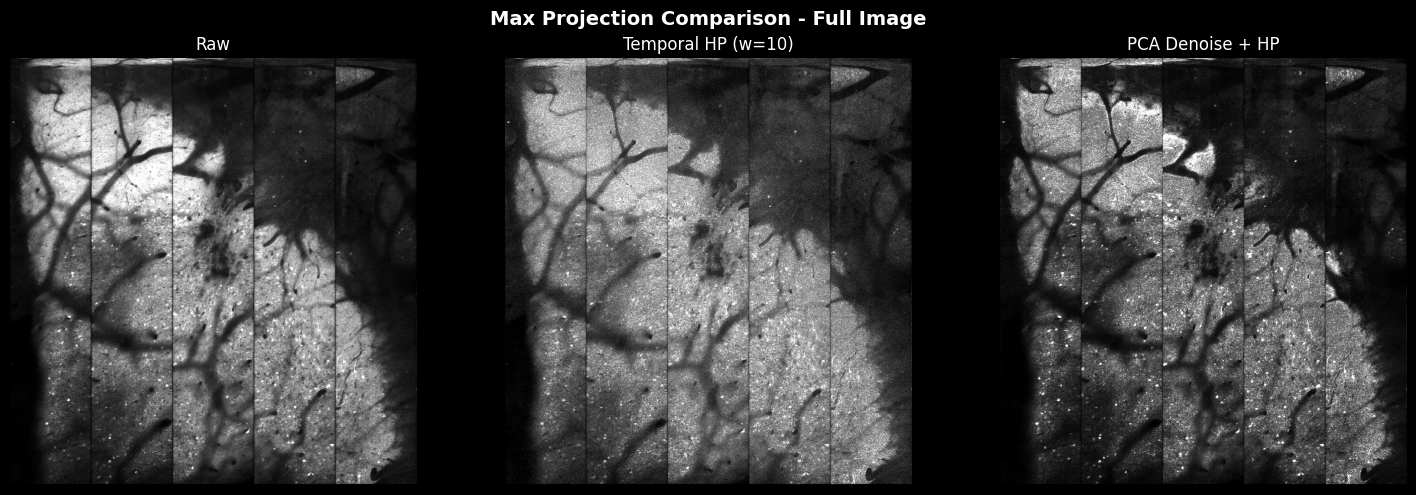

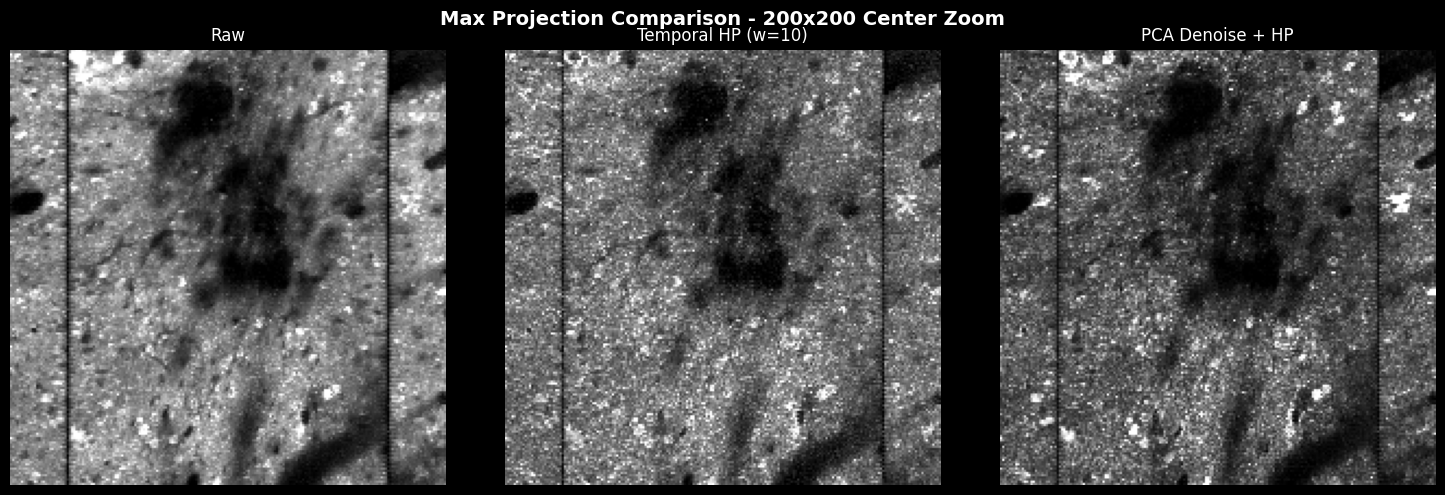

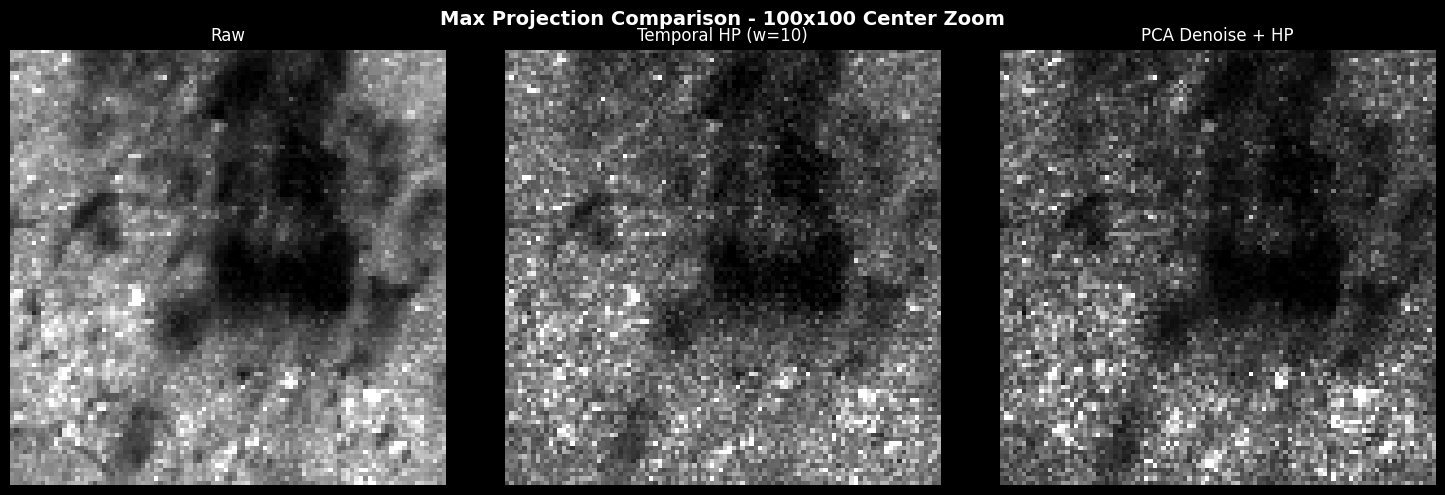

In [20]:
# Plot comparison of max projections
def normalize99(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

Ly, Lx = max_proj_raw.shape
cy, cx = Ly // 2, Lx // 2

projections = {
    "Raw": max_proj_raw,
    f"Temporal HP (w={HIGH_PASS})": max_proj_hp,
    f"PCA Denoise + HP": max_proj_denoised,
}

# Full image comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, proj) in zip(axes, projections.items()):
    ax.imshow(normalize99(proj), cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.suptitle("Max Projection Comparison - Full Image", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Zoomed comparison (200x200 center)
zs = 200
y1, y2 = cy - zs//2, cy + zs//2
x1, x2 = cx - zs//2, cx + zs//2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, proj) in zip(axes, projections.items()):
    ax.imshow(normalize99(proj[y1:y2, x1:x2]), cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.suptitle(f"Max Projection Comparison - {zs}x{zs} Center Zoom", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Zoomed comparison (100x100 center)
zs = 100
y1, y2 = cy - zs//2, cy + zs//2
x1, x2 = cx - zs//2, cx + zs//2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, proj) in zip(axes, projections.items()):
    ax.imshow(normalize99(proj[y1:y2, x1:x2]), cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.suptitle(f"Max Projection Comparison - {zs}x{zs} Center Zoom", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# Run Cellpose on each preprocessing variant
from cellpose import models, core

model = models.CellposeModel(gpu=core.use_gpu())
DIAMETER = 6
CELLPROB_THRESHOLD = -6.0

cellpose_results = {}

for name, proj in projections.items():
    img = normalize99(proj)
    masks, _, _ = model.eval(
        img,
        diameter=DIAMETER,
        cellprob_threshold=CELLPROB_THRESHOLD,
        flow_threshold=0.0,
    )
    n_cells = masks.max()
    cellpose_results[name] = {'masks': masks, 'n_cells': n_cells, 'proj': proj}
    print(f"{name}: {n_cells} cells")

print(f"\nCell count summary:")
for name, r in cellpose_results.items():
    print(f"  {name}: {r['n_cells']} cells")

Resizing is deprecated in v4.0.1+


Raw: 745 cells


Resizing is deprecated in v4.0.1+


Temporal HP (w=10): 347 cells


Resizing is deprecated in v4.0.1+


PCA Denoise + HP: 616 cells

Cell count summary:
  Raw: 745 cells
  Temporal HP (w=10): 347 cells
  PCA Denoise + HP: 616 cells


In [3]:
# Visualize Cellpose results with mask overlays
def mask_overlay(img, masks, alpha=0.4):
    from matplotlib.colors import hsv_to_rgb
    img_norm = normalize99(img)
    rgb = np.stack([img_norm]*3, axis=-1)
    if masks.max() > 0:
        n = masks.max()
        np.random.seed(42)
        colors = np.zeros((n+1, 3))
        for i in range(1, n+1):
            colors[i] = hsv_to_rgb([np.random.rand(), 0.8, 0.9])
        mask_rgb = colors[masks]
        mask_area = masks > 0
        rgb[mask_area] = (1-alpha)*rgb[mask_area] + alpha*mask_rgb[mask_area]
    return np.clip(rgb, 0, 1)

# Full image with masks
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, r) in zip(axes, cellpose_results.items()):
    overlay = mask_overlay(r['proj'], r['masks'])
    ax.imshow(overlay)
    ax.set_title(f"{name}\n{r['n_cells']} cells")
    ax.axis('off')
plt.suptitle(f"Cellpose Detection (d={DIAMETER}) - Full Image", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 200x200 zoom with masks
zs = 200
y1, y2 = cy - zs//2, cy + zs//2
x1, x2 = cx - zs//2, cx + zs//2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, r) in zip(axes, cellpose_results.items()):
    overlay = mask_overlay(r['proj'], r['masks'])
    zoom_masks = r['masks'][y1:y2, x1:x2]
    n_zoom = len(np.unique(zoom_masks)) - 1
    ax.imshow(overlay[y1:y2, x1:x2])
    ax.set_title(f"{name}\n{n_zoom} cells in view")
    ax.axis('off')
plt.suptitle(f"Cellpose Detection (d={DIAMETER}) - {zs}x{zs} Center Zoom", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 100x100 zoom with masks
zs = 100
y1, y2 = cy - zs//2, cy + zs//2
x1, x2 = cx - zs//2, cx + zs//2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, r) in zip(axes, cellpose_results.items()):
    overlay = mask_overlay(r['proj'], r['masks'])
    zoom_masks = r['masks'][y1:y2, x1:x2]
    n_zoom = len(np.unique(zoom_masks)) - 1
    ax.imshow(overlay[y1:y2, x1:x2])
    ax.set_title(f"{name}\n{n_zoom} cells in view")
    ax.axis('off')
plt.suptitle(f"Cellpose Detection (d={DIAMETER}) - {zs}x{zs} Center Zoom", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [1]:
!uv pip install ../../../suite2p
!uv pip install ../../../mbo_utilities

Using Python 3.12.9 environment at: C:\Users\RBO\repos\LBM-Suite2p-Python\.venv
Resolved 59 packages in 226ms
   Building suite2p-mbo @ file:///C:/Users/RBO/repos/suite2p
      Built suite2p-mbo @ file:///C:/Users/RBO/repos/suite2p
Prepared 1 package in 2.08s
Uninstalled 1 package in 25ms
Installed 1 package in 34ms
 - suite2p-mbo==2.0.0
 + suite2p-mbo==2.0.1 (from file:///C:/Users/RBO/repos/suite2p)
Using Python 3.12.9 environment at: C:\Users\RBO\repos\LBM-Suite2p-Python\.venv
Resolved 157 packages in 817ms
   Building mbo-utilities @ file:///C:/Users/RBO/repos/mbo_utilities
      Built mbo-utilities @ file:///C:/Users/RBO/repos/mbo_utilities
Prepared 1 package in 1.57s
Uninstalled 1 package in 16ms
Installed 1 package in 34ms
 - mbo-utilities==2.3.0
 + mbo-utilities==2.3.1 (from file:///C:/Users/RBO/repos/mbo_utilities)


start here

In [6]:
from pathlib import Path
import lbm_suite2p_python as lsp
import mbo_utilities as mbo

OUTPUT_DIR = Path(r"D:/cj/2025-11-21/v7")

raw_paths = [
    r"\\rbo-s1\S1_DATA\lbm\christian\2025-11-21\raw\vdaq0",
    r"\\rbo-s1\S1_DATA\lbm\christian\2025-11-21\raw\vdaq1",
]

for path in raw_paths:
    path = Path(path)

    ops_paths = lsp.pipeline(
        input_data=path,
        save_path=OUTPUT_DIR,
        planes=None,
        force_reg=False,
        force_detect=False,
        ops={
            # "roidetect":1,
            "anatomical_only":4,
            "two_step_registration": 0,
            "high_pass":0,
            # "preclassify": 0,
            "diameter": 4,
            # "nbinned": 0,
            "denoise": 0,
            "spatial_hp_cp": 0,
            "cellprob_threshold": -6,
            # "skip_classification": True,
            "flow_threshold": 0,
            "accept_all_cells": True,

        },
        cell_filters=[{"name": "max_diameter", "max_diameter_um": 52}],
        accept_all_cells = True,
        reader_kwargs={
            "fix_phase": True,
            "use_fft": True,
        },
        writer_kwargs={
            "output_suffix": f"_{path.name}",
        },
    )

    print(f"Results: {ops_paths}")

Loading input data...
  Input: \\rbo-s1\S1_DATA\lbm\christian\2025-11-21\raw\vdaq0


Counting frames:   0%|          | 0/1 [00:00<?, ?it/s]

  Loaded as: MboRawArray

Dataset info:
  Shape: (970, 2, 772, 735)
  Frames: 970
  Planes: 2
  Dimensions: 772 x 735
  Phase correction: True
  FFT subpixel: True
  Frame rate: 5.40 Hz
  ROIs: 5
Importing suite2p packages...

Processing plan:
  Planes: [1, 2]
  Output: D:\cj\2025-11-21\v7

Processing plane 1/2
  Writing binary (970 frames, 772x735)...


Saving data_raw.bin:   0%|          | 0/105 [00:00<?, ?it/s]

  Running Suite2p pipeline...
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 16.40 sec.
Registered 500/970 in 20.27s
Registered 970/970 in 38.76s
----------- Total 57.30 sec
----------- ROI DETECTION
Skipping temporal binning (nbinned=0 or nbinned >= nframes)
Binned movie of size [970,772,735] created in 2.35 sec.
>>>> CELLPOSE finding masks in max_proj


...

  Running Suite2p pipeline...
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 16.07 sec.
Registered 500/970 in 19.97s
Registered 970/970 in 38.48s
----------- Total 56.76 sec
----------- ROI DETECTION
Skipping temporal binning (nbinned=0 or nbinned >= nframes)
Binned movie of size [970,772,735] created in 2.22 sec.
>>>> CELLPOSE finding masks in max_proj


model_type argument is not used in v4.0.1+. Ignoring this argument...


!NOTE! diameter set to 4.00 for cell detection with cellpose


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Resizing is deprecated in v4.0.1+


>>>> 606 masks detected, median diameter = 8.59 
Detected 606 ROIs, 31.18 sec
After removing overlaps, 606 ROIs remain
----------- Total 35.92 sec.
----------- EXTRACTION
Masks created, 0.98 sec.
Extracted fluorescence from 606 ROIs in 970 frames, 1.04 sec.
----------- Total 2.08 sec.
----------- CLASSIFICATION
['npix_norm', 'compact', 'skew']
NOTE: accept_all_cells=True, marking all ROIs as cells
----------- SPIKE DECONVOLUTION
----------- Total 0.03 sec.
  Applying cell filters...
filter_by_max_diameter: removed 48 ROIs (max=15.7px)
Saved filtered iscell to D:\cj\2025-11-21\v7\plane02_vdaq1\iscell.npy
apply_filters: 48 total ROIs removed (558/606 cells remaining)
  Computing dF/F...
  Generating plots...
Plotting results for 558 accepted / 48 rejected ROIs
  Completed plane02_vdaq1 in 146.6s

Generating volumetric statistics...

Pipeline complete!
  Processed: 2 planes
  Time: 295.6s
  Output: D:\cj\2025-11-21\v7
Results: [WindowsPath('D:/cj/2025-11-21/v7/plane01_vdaq1/ops.npy'), Win

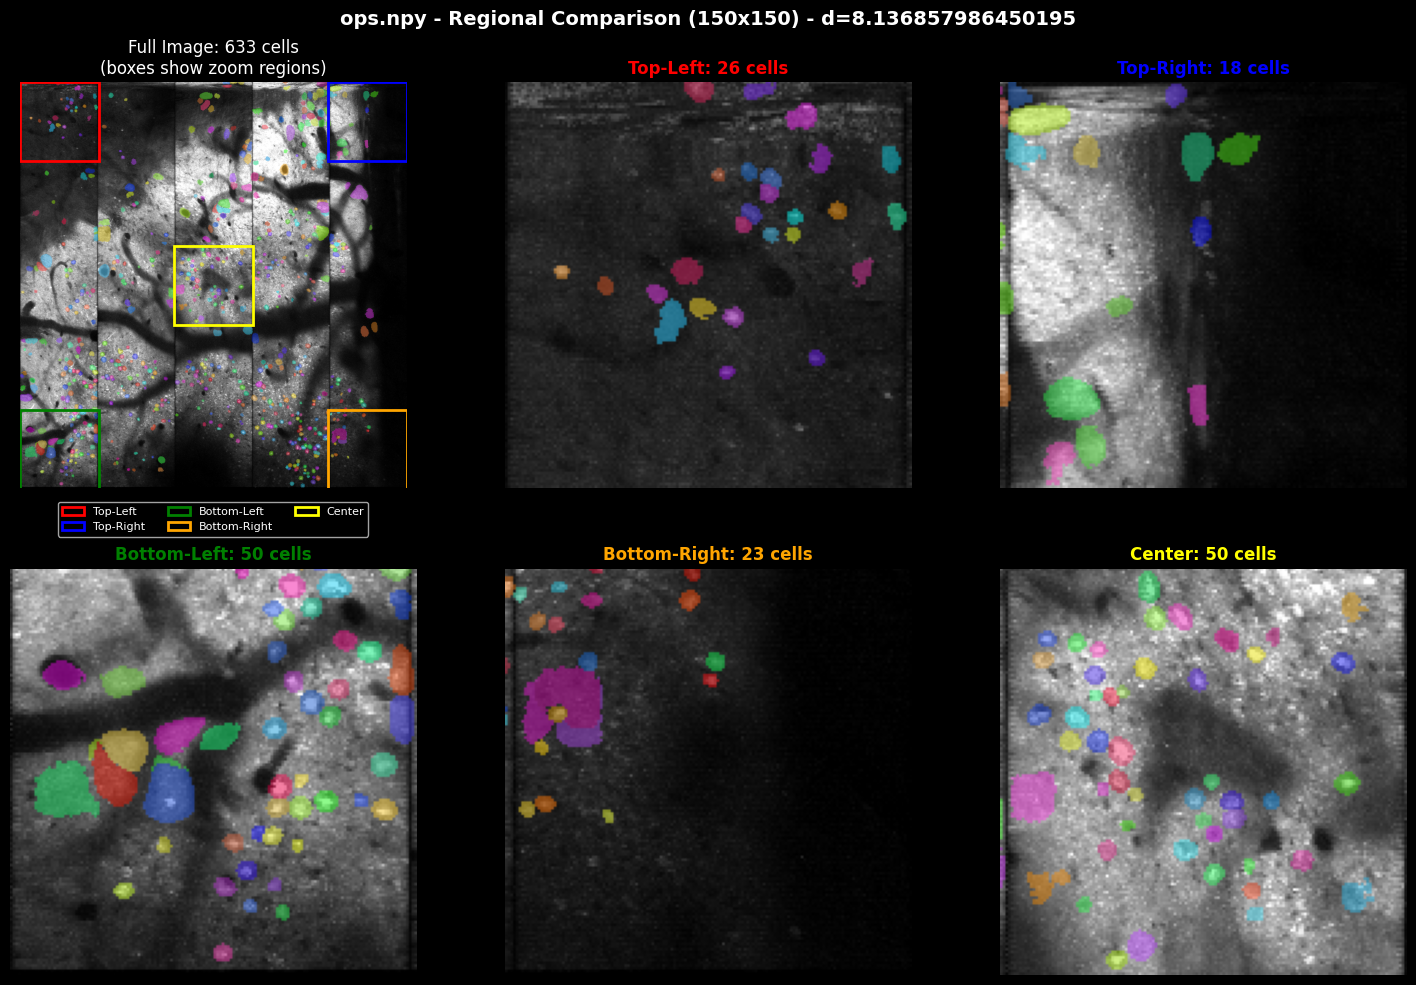

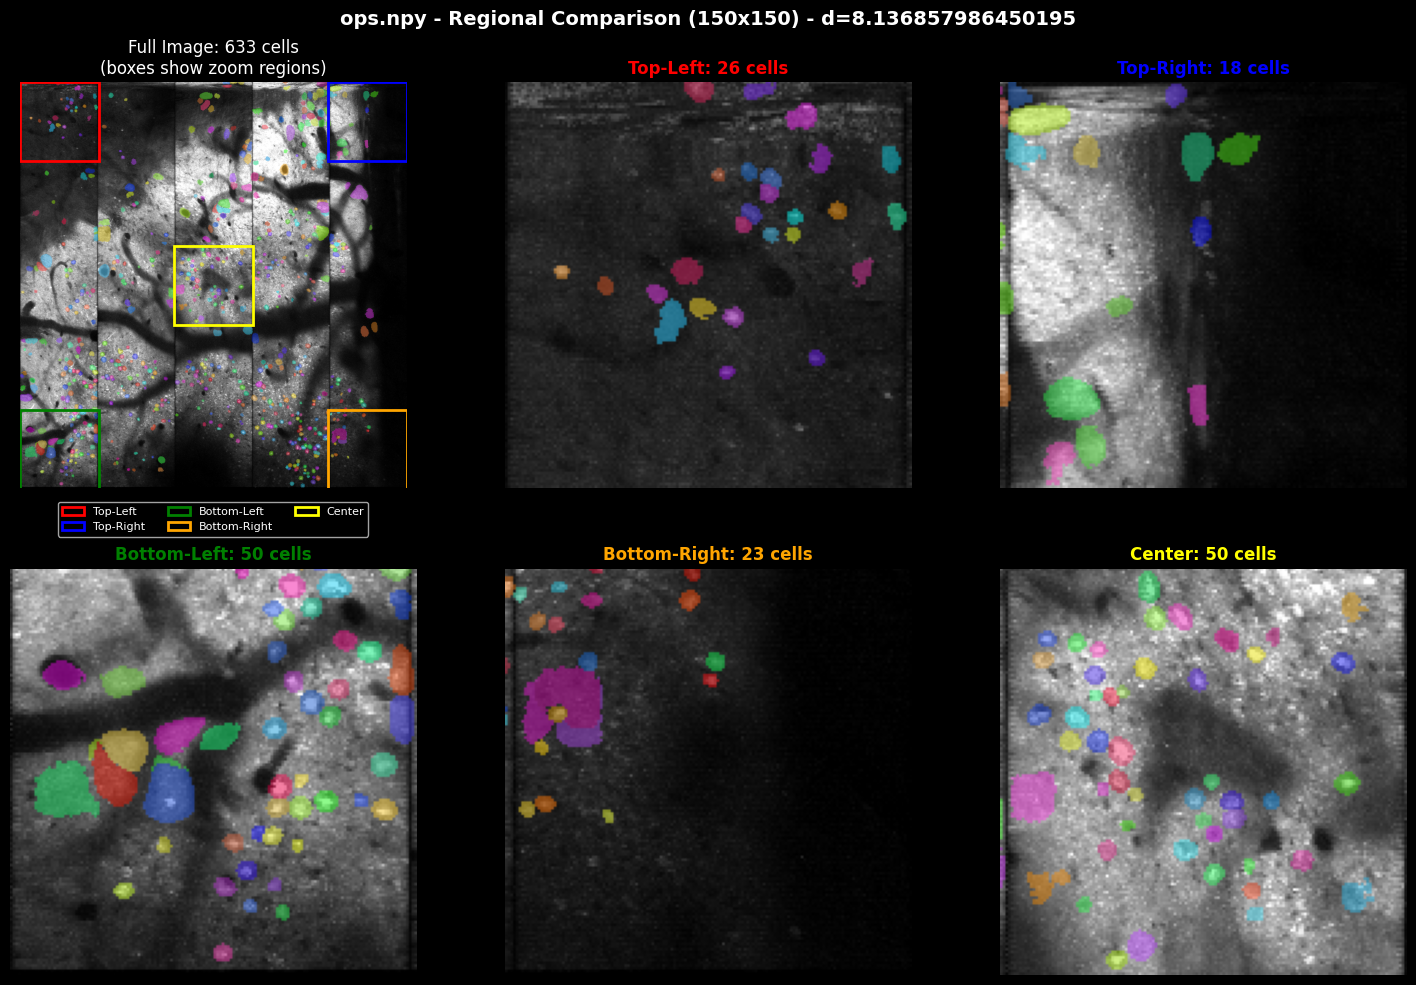

In [5]:
lsp.plot_regional_zoom(plane_dir.joinpath("ops.npy"))

Filtered 97 ROIs with diameter > 12.7 px


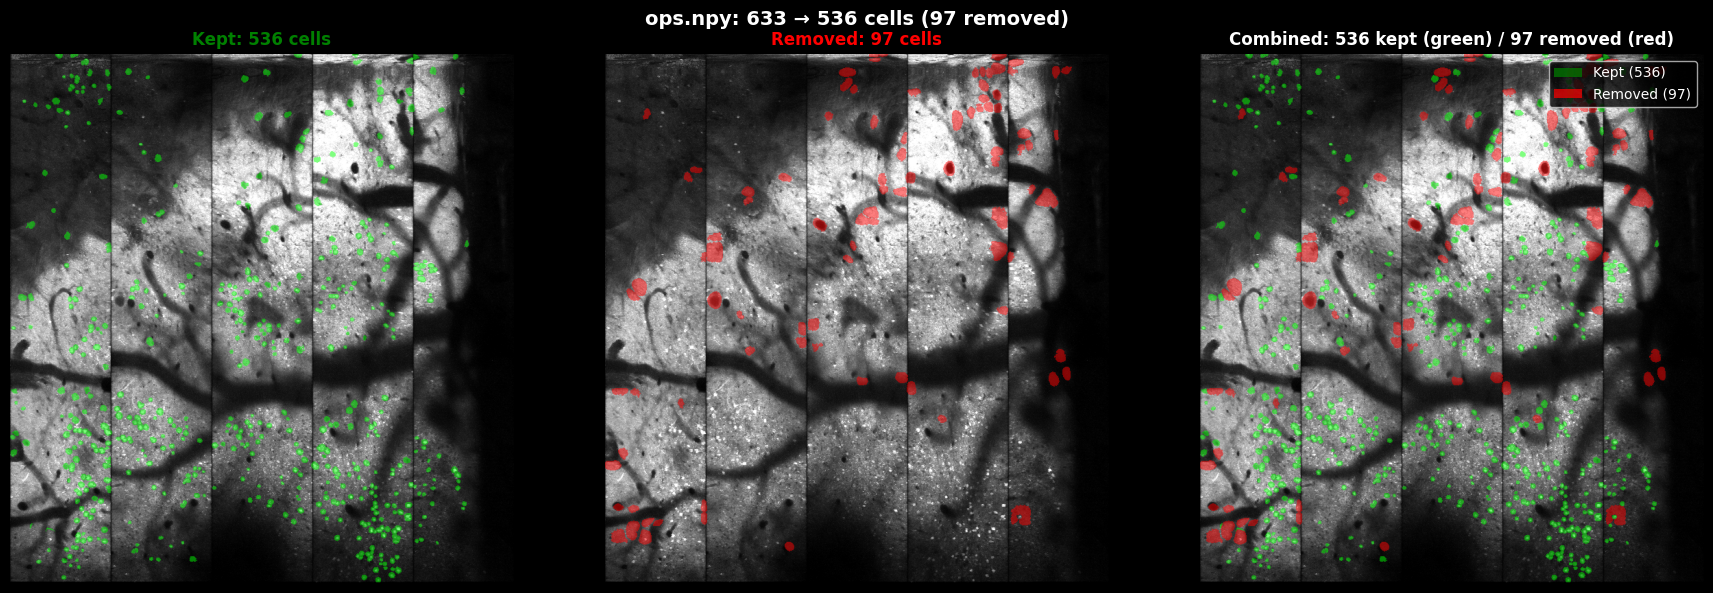

In [5]:
from pathlib import Path
import lbm_suite2p_python as lsp
# Load results from a plane directory
plane_dir = Path("D:/cj/2025-11-21/v4/plane01_vdaq0")
ops = lsp.load_ops(plane_dir.joinpath("ops.npy"))
res = lsp.load_planar_results(plane_dir.joinpath("ops.npy"))

iscell = res["iscell"]
stat = res["stat"]

filtered_iscell, removed_mask, diameters, threshold_px = lsp.filter_by_max_diameter(
    iscell, stat, max_diameter_um=42, ops=ops
)

# Plot kept vs removed cells
fig = lsp.plot_filtered_cells(
    plane_dir.joinpath("ops.npy"),
    iscell,
    iscell_filtered=filtered_iscell,
)

save the new iscell

In [ ]:
import numpy as np

# Load original iscell (2D array with probabilities)
iscell_original = np.load(plane_dir / "iscell.npy")

# Apply the filter to the first column (keeps probabilities intact)
iscell_original[removed_mask, 0] = 0  # Mark removed cells as non-cells

# Save back
np.save(plane_dir / "iscell.npy", iscell_original)

In [8]:
# Load ops from registration
ops_path = ops_paths[0]
ops = np.load(ops_path, allow_pickle=True).item()
max_proj = ops["max_proj"].astype(np.float32)
Ly, Lx = ops["Ly"], ops["Lx"]

print(f"Loaded max_proj: {Ly}x{Lx}")
def normalize99(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

# Best params from debug_lsp_pipeline: d=2, spa=0
DIAMETER = 4
CELLPROB_THRESHOLD = -6.0

model = models.CellposeModel(gpu=core.use_gpu())
img = normalize99(max_proj)

masks, flows, styles = model.eval(
    img,
    diameter=DIAMETER,
    cellprob_threshold=CELLPROB_THRESHOLD,
    flow_threshold=0.0,
)

n_cells = masks.max()
print(f"Detected {n_cells} cells")

Loaded max_proj: 772x735


Resizing is deprecated in v4.0.1+


Detected 877 cells
